In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")
RANDOM_STATE = 42

In [89]:
# Загрузка данных
df = pd.read_csv("../data/raw/creditcard_2023.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (568630, 31)


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [121]:
# Проверка дубликатов
df.duplicated().sum()

np.int64(0)

In [90]:
# Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [91]:
# Статистика по числовым колонкам
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.323544e-16,-3.518788e-17,-2.879008e-17,7.197521e-18,-3.838678e-17,-3.198898e-17,2.069287e-17,9.116859e-17,...,4.758361e-17,5.398140e-18,5.395017e-18,-1.999311e-18,-3.028957e-17,-7.547400e-18,-3.598760e-17,2.499139e-17,12041.957635,0.5
std,164149.486122,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [119]:
# Проверка на выбросы в V-признаках (PCA-transformed features)
v_features = [f"V{i}" for i in range(1, 29)]

# Считаем количество выбросов по правилу 3 сигм
outliers_count = {}
for col in v_features:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] > mean + 3*std) | (df[col] < mean - 3*std)]
    outliers_count[col] = len(outliers)

outliers_df = pd.DataFrame(list(outliers_count.items()), columns=['Feature', 'Outliers'])
outliers_df = outliers_df.sort_values('Outliers', ascending=False)

print("Количество выбросов в V-признаках (3 сигмы):")
print(outliers_df.head(10))

Количество выбросов в V-признаках (3 сигмы):
   Feature  Outliers
7       V8     17459
26     V27     13337
27     V28     12590
1       V2     12203
19     V20     10646
20     V21     10165
22     V23      9656
21     V22      9652
24     V25      7758
6       V7      7140


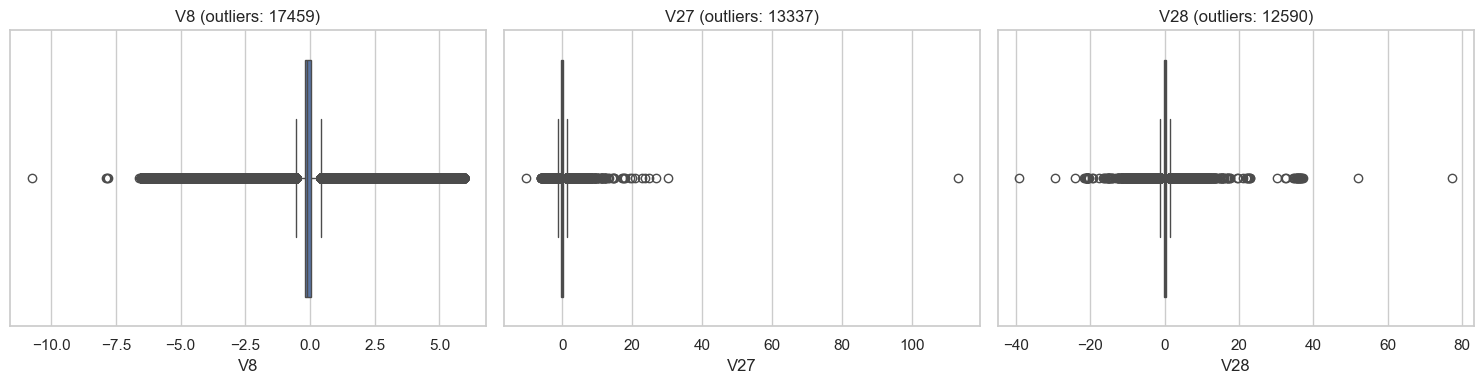

In [120]:
# Визуализация выбросов в топ-3 признаках
fig, axes = plt.subplots(1, 3, figsize=(15,4))
top_outliers = outliers_df.head(3)['Feature'].values

for i, feat in enumerate(top_outliers):
    sns.boxplot(x=df[feat], ax=axes[i])
    axes[i].set_title(f'{feat} (outliers: {outliers_count[feat]})')

plt.tight_layout()
plt.show()

In [92]:
# Проверка баланса классов
class_counts = df["Class"].value_counts()
print(class_counts)
print(f"Процент мошенничества: {class_counts[1]/len(df)*100:.2f}%")

Class
0    284315
1    284315
Name: count, dtype: int64
Процент мошенничества: 50.00%


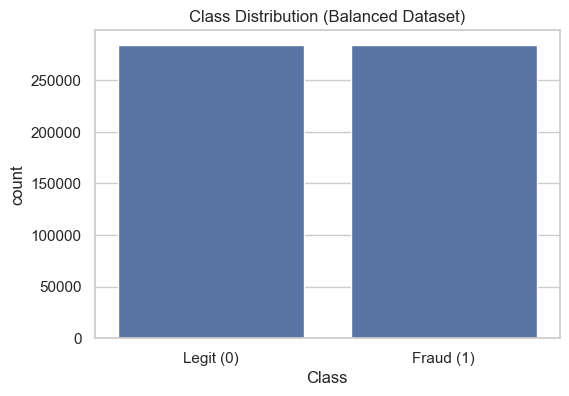

In [93]:
# Визуализация баланса классов
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (Balanced Dataset)")
plt.xticks([0,1], ["Legit (0)", "Fraud (1)"])
plt.show()

In [94]:
# Статистика Amount по классам
print("=== Legit Transactions ===")
print(df[df["Class"]==0]["Amount"].describe())
print("\n=== Fraud Transactions ===")
print(df[df["Class"]==1]["Amount"].describe())

=== Legit Transactions ===
count    284315.000000
mean      12026.313506
std        6929.500715
min          50.120000
25%        6034.540000
50%       11996.900000
75%       18040.265000
max       24039.930000
Name: Amount, dtype: float64

=== Fraud Transactions ===
count    284315.000000
mean      12057.601763
std        6909.750891
min          50.010000
25%        6074.640000
50%       12062.450000
75%       18033.780000
max       24039.930000
Name: Amount, dtype: float64


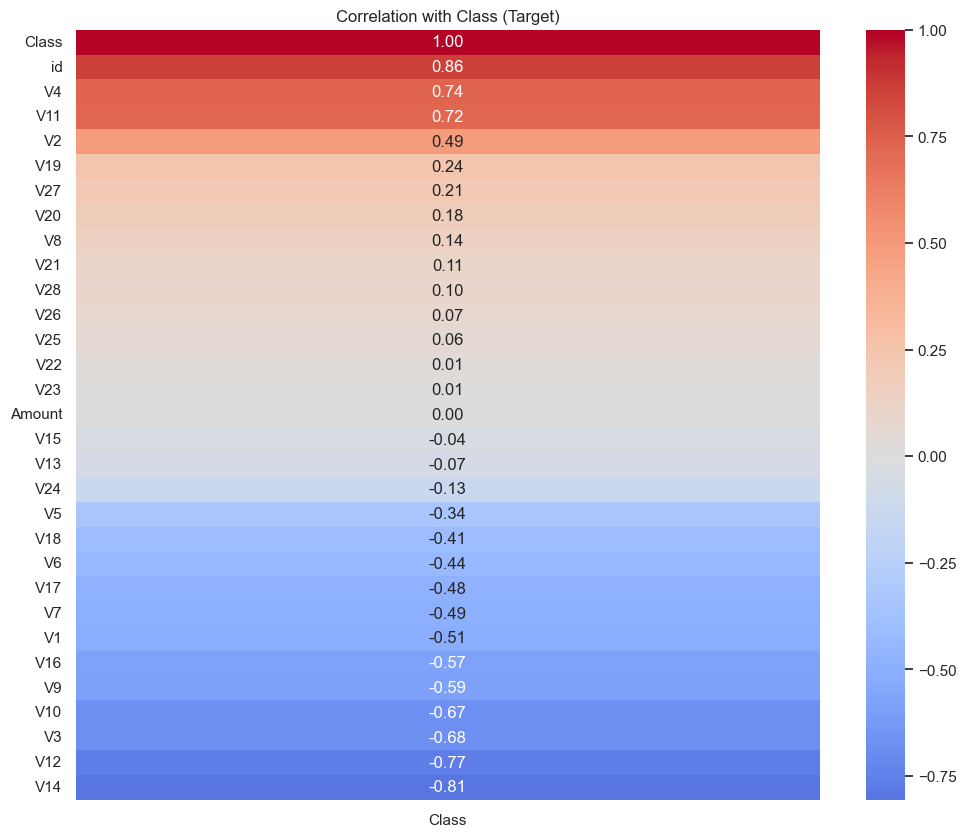

In [95]:
# Корреляционная матрица
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix[["Class"]].sort_values(by="Class", ascending=False), 
            annot=True, cmap="coolwarm", center=0, fmt='.2f')
plt.title("Correlation with Class (Target)")
plt.show()

In [96]:
# Подготовка данных для PCA
X_raw = df.drop(["Class", "id"], axis=1)
y = df["Class"]

print(f"Feature matrix shape: {X_raw.shape}")

Feature matrix shape: (568630, 29)


In [122]:
# Масштабирование перед PCA
scaler_for_pca = StandardScaler()
X_scaled_for_pca = scaler_for_pca.fit_transform(X_raw)

In [124]:
# PCA с 2 компонентами
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_for_pca)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio: [0.33872158 0.09688719]
Total explained: 43.56%


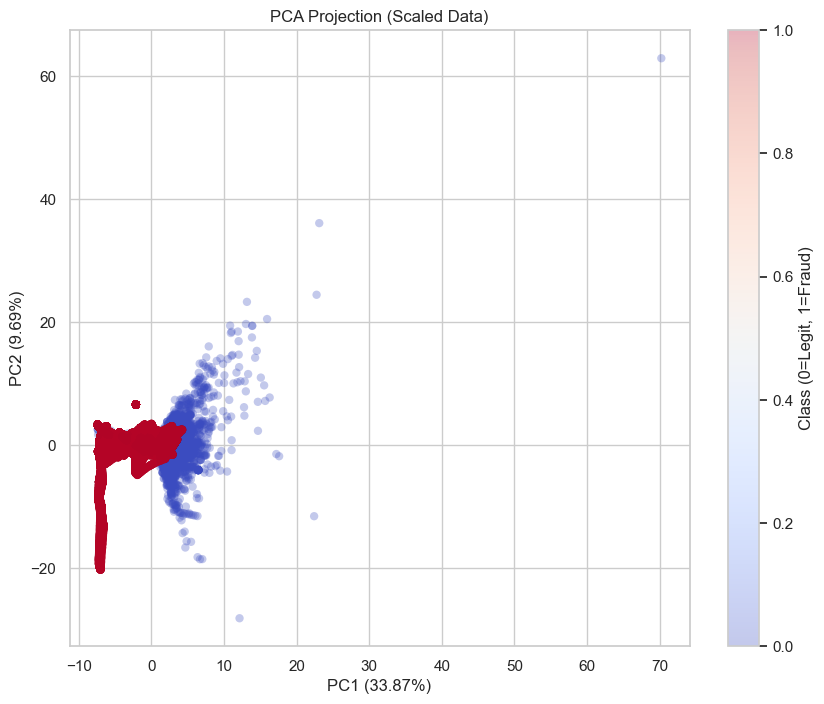

In [125]:
# Визуализация PCA
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.3, 
                       cmap='coolwarm', edgecolors='none')
plt.colorbar(scatter, label='Class (0=Legit, 1=Fraud)')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title("PCA Projection (Scaled Data)")
plt.show()

In [130]:
# Подготовка данных для обучения

X = df.drop(["Class", "id"], axis=1)
y = df["Class"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance:\n{y.value_counts()}")

X shape: (568630, 29)
y shape: (568630,)
Class balance:
Class
0    284315
1    284315
Name: count, dtype: int64


In [131]:
# Разделение на train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.3, 
    stratify=y, 
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    stratify=y_temp, 
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (398041, 29)
Val: (85294, 29)
Test: (85295, 29)


In [133]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [135]:
# Сохранение обработанных данных
import os
os.makedirs("./data/processed", exist_ok=True)

np.save("../data/processed/X_train.npy", X_train_scaled)
np.save("../data/processed/X_val.npy", X_val_scaled)
np.save("../data/processed/X_test.npy", X_test_scaled)
np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_val.npy", y_val.values)
np.save("../data/processed/y_test.npy", y_test.values)
